<h2>CHARLES BERCHES<br>JOSHUA DEÑADO<br>BSIT-3A</h2>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score, mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('datasets//Family Income and Expenditure.csv')
df

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


In [3]:
for x in df.select_dtypes(include='object').columns:
    df[x] = df[x].astype('category')

df.dtypes

Total Household Income                              int64
Region                                           category
Total Food Expenditure                              int64
Main Source of Income                            category
Agricultural Household indicator                    int64
Bread and Cereals Expenditure                       int64
Total Rice Expenditure                              int64
Meat Expenditure                                    int64
Total Fish and  marine products Expenditure         int64
Fruit Expenditure                                   int64
Vegetables Expenditure                              int64
Restaurant and hotels Expenditure                   int64
Alcoholic Beverages Expenditure                     int64
Tobacco Expenditure                                 int64
Clothing, Footwear and Other Wear Expenditure       int64
Housing and water Expenditure                       int64
Imputed House Rental Value                          int64
Medical Care E

In [4]:
for col in ['Household Head Occupation', 'Household Head Class of Worker', 'Toilet Facilities']:
    df[col] = df[col].cat.add_categories(['unaccounted'])
    df[col] = df[col].fillna('unaccounted')

df.isnull().sum()

Total Household Income                           0
Region                                           0
Total Food Expenditure                           0
Main Source of Income                            0
Agricultural Household indicator                 0
Bread and Cereals Expenditure                    0
Total Rice Expenditure                           0
Meat Expenditure                                 0
Total Fish and  marine products Expenditure      0
Fruit Expenditure                                0
Vegetables Expenditure                           0
Restaurant and hotels Expenditure                0
Alcoholic Beverages Expenditure                  0
Tobacco Expenditure                              0
Clothing, Footwear and Other Wear Expenditure    0
Housing and water Expenditure                    0
Imputed House Rental Value                       0
Medical Care Expenditure                         0
Transportation Expenditure                       0
Communication Expenditure      

<h1>DIAGNOSTIC</h1>

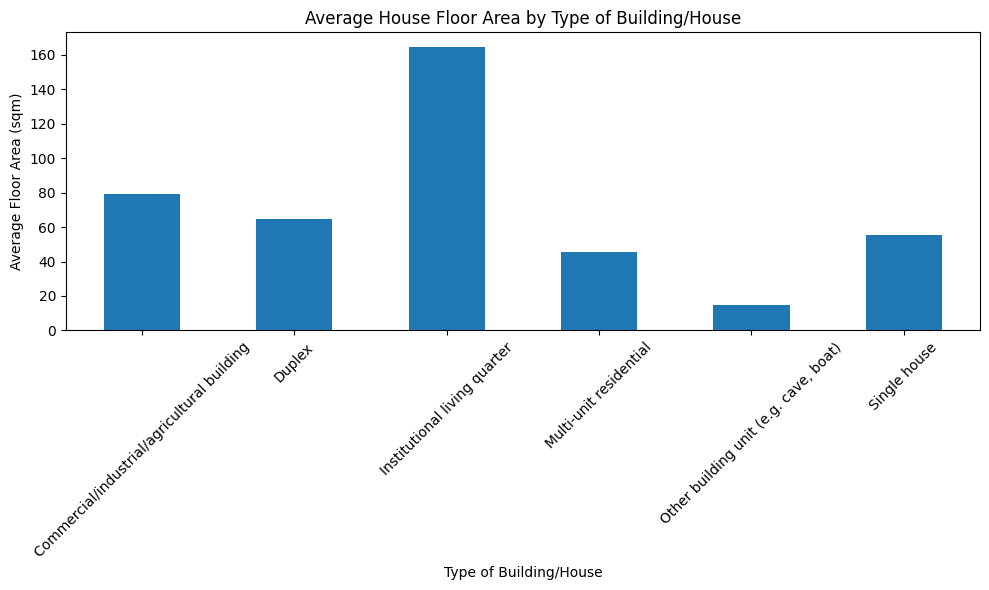

In [5]:
# Average House Floor Area by Type of Building/House
plt.figure(figsize=(10,6))
df.groupby('Type of Building/House')['House Floor Area'].mean().plot(kind='bar')

plt.title('Average House Floor Area by Type of Building/House')
plt.xlabel('Type of Building/House')
plt.ylabel('Average Floor Area (sqm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<h3>INSIGHT #</h3>
<p>This shows the average floor area for different types of buildings or houses makes it easy to see how living space changes depending on the type of home people live in. Institutional living quarters have the biggest average floor area among all the groups. This makes sense because places like dorms, staff housing, or buildings with shared rooms are usually built to hold many people, so they naturally require more space.
    
Commercial, industrial, and agricultural buildings also have large average floor areas, possibly because these structures were not made for families at first and were designed with wide, open spaces. Single houses fall somewhere in the middle, showing typical house sizes for normal families. On the other hand, “Other building units,” such as boats, caves, or improvised shelters, have the smallest living spaces, which is expected because they are not really meant to serve as permanent homes.
    
Overall, the graph shows that the type of building has a big effect on how much living space households have, with institutional and commercial structures offering the most space and unusual or temporary shelters offering the least.</p>
<hr>

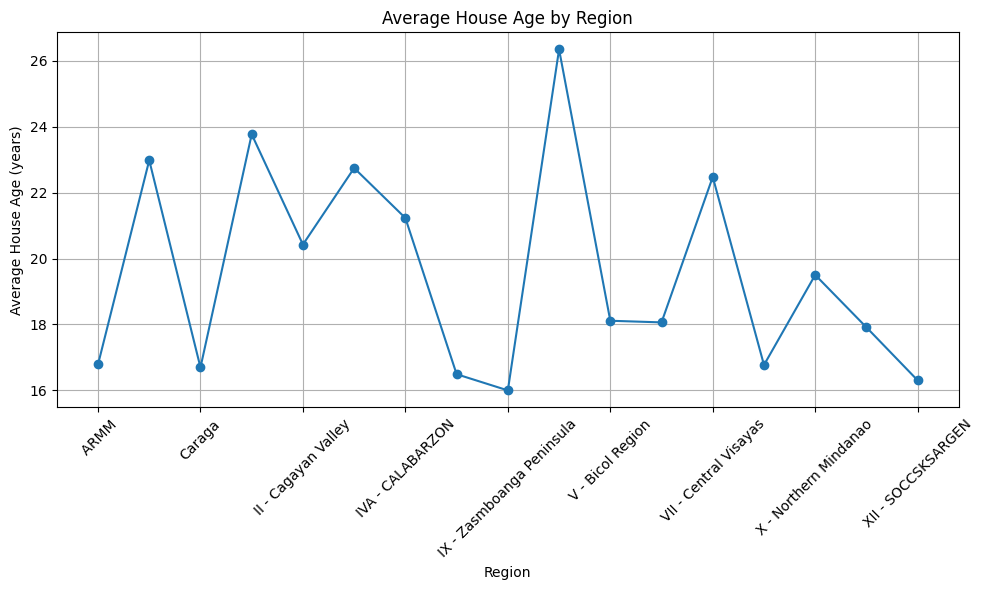

In [6]:
# Average House Age by Region
plt.figure(figsize=(10,6))
df.groupby('Region')['House Age'].mean().plot(kind='line', marker='o')

plt.title('Average House Age by Region')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.ylabel('Average House Age (years)')
plt.grid(True)
plt.tight_layout()
plt.show()

<h3>INSIGHT #</h3>
<p>This shows the average age of houses in each region reveals that some regions have older homes while others have newer ones. Regions like the Zamboanga Peninsula, the Cagayan Valley, and the Bicol Region have some of the oldest houses, with average ages reaching around twenty-three to twenty-six years. This suggests that these areas might have long-established communities where homes stay in families for many years, or where new construction happens slowly.
    
In contrast, regions such as SOCSKSARGEN, Caraga, and Northern Mindanao have younger houses, which could mean that these places have had more recent construction, faster growth, or more modern housing projects. These differences can be caused by many things, such as economic conditions, how quickly towns grow, or government programs that build new houses. The ups and downs in the graph show that the age of houses across the country varies a lot, with some places having older, traditional homes and others having newer, more recently built ones.</p>
<hr>

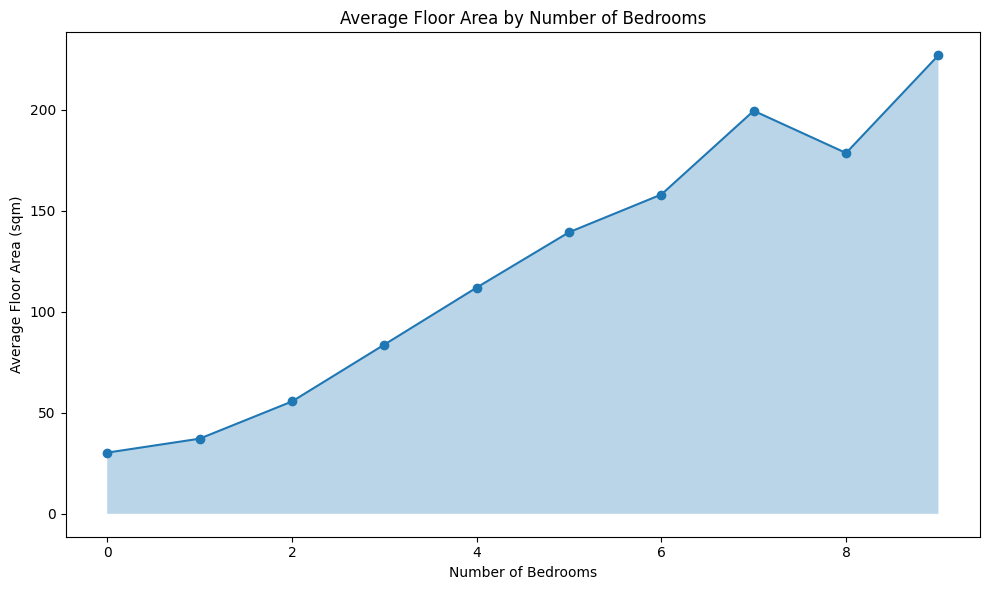

In [7]:
# Relationship Between Bedrooms and Floor Area
bedroom_area = df.groupby('Number of bedrooms')['House Floor Area'].mean()

plt.figure(figsize=(10,6))
plt.fill_between(bedroom_area.index, bedroom_area.values, alpha=0.3)
plt.plot(bedroom_area.index, bedroom_area.values, marker='o')

plt.title('Average Floor Area by Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Average Floor Area (sqm)')
plt.tight_layout()
plt.show()

<h3>INSIGHT #</h3>
<p>This shows the relationship between the number of bedrooms and the average floor area clearly explains how house size increases as more bedrooms are added. The trend rises steadily, starting from very small homes with zero or one bedroom and moving toward much larger floor areas for houses with several bedrooms. For example, homes with only one or two bedrooms have relatively small floor areas, which fits the idea that smaller families or individuals usually do not need as much space.
    
As the number of bedrooms increases to three, four, or five, the average floor area grows much more noticeably, showing that families who need more bedrooms also require bigger living spaces overall. There is a small decrease at eight bedrooms, but the floor area rises again sharply at nine bedrooms, which suggests that extremely large homes can vary depending on design or purpose.
    
Overall, the graph shows a very clear pattern: more bedrooms almost always mean a bigger house, which makes sense because additional bedrooms require extra rooms, hallways, and sometimes larger common areas.</p>
<hr>

<h1>PREDICTIVE</h1>

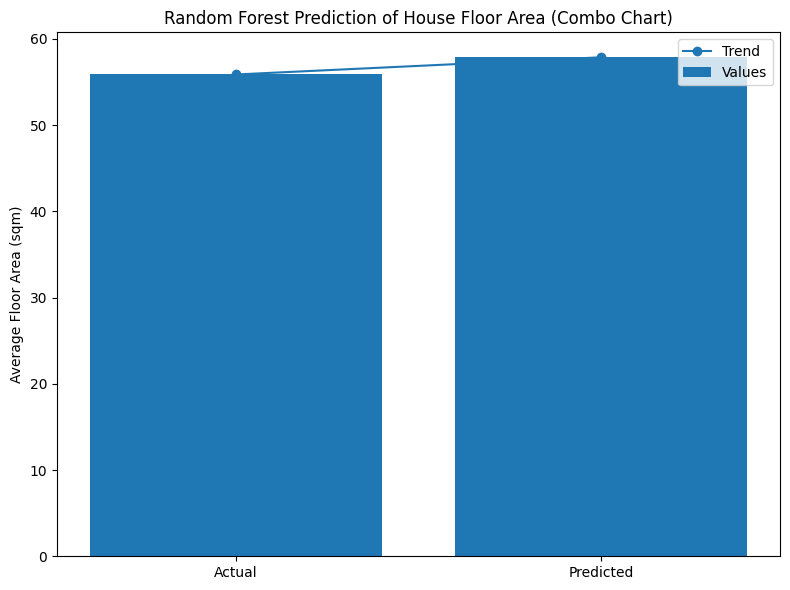

In [8]:
# Random Forest Regression – Predict House Floor Area
numeric_cols = df.select_dtypes(include=['int64']).columns.tolist()

X = df[numeric_cols].drop('House Floor Area', axis=1)
y = df['House Floor Area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # train-test split

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_test)

result_df = pd.DataFrame({'Actual': y_test, 'Predicted': preds}) # aggregate for visualization
avg_result = result_df.mean()

plt.figure(figsize=(8,6))
plt.bar(['Actual','Predicted'], avg_result.values, label='Values')
plt.plot(['Actual','Predicted'], avg_result.values, marker='o', label='Trend')

plt.title('Random Forest Prediction of House Floor Area (Combo Chart)')
plt.ylabel('Average Floor Area (sqm)')
plt.legend()
plt.tight_layout()
plt.show()

<h3>INSIGHT #</h3>
<p>When we compare the actual values to the predicted values, we can see that both numbers are very close to each other. This means the model is doing a good job at estimating the house floor area.
    
The bar chart shows the actual and predicted averages side by side, and they are almost the same height. The line on the chart also shows that the trend between the two values is almost flat, which means there is only a small difference between what the model predicted and the real value. 

Overall, the model is accurate, and it can be trusted to make good predictions about house floor area using the given data.</p>
<hr>

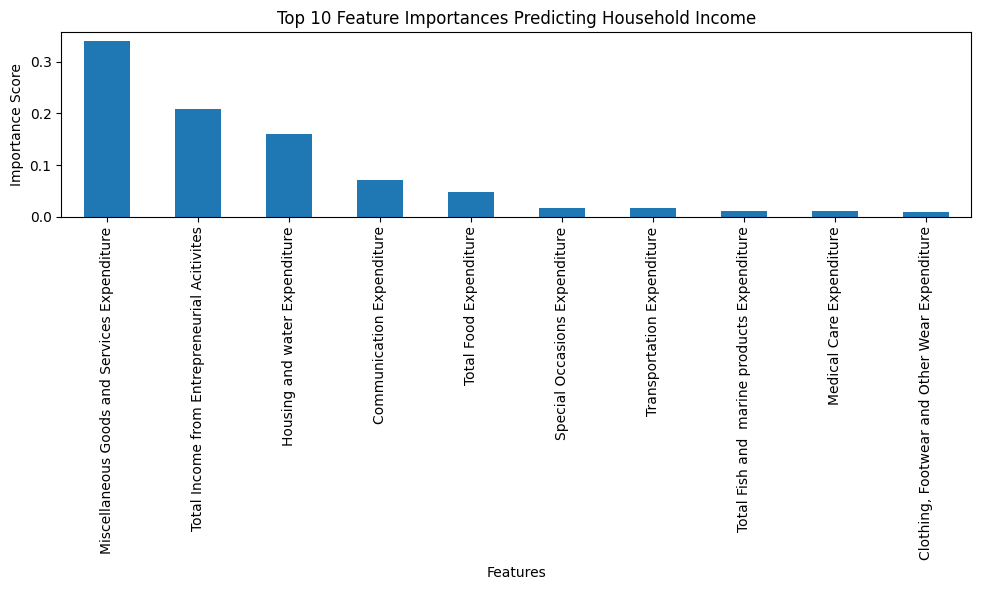

In [12]:
# Feature Importance Bar Chart – Predict Total Household Income
y = df['Total Household Income']

X = df.select_dtypes(include=['int64']).drop('Total Household Income', axis=1) # selectting numeric predictors

rf_income = RandomForestRegressor(random_state=42)
rf_income.fit(X, y)

importances = pd.Series(rf_income.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
importances.plot(kind='bar')

plt.title('Top 10 Feature Importances Predicting Household Income')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

<h3>INSIGHT #</h3>
<p>The feature with the highest importance is Miscellaneous Goods and Services Expenditure, meaning households that spend more on various goods and services usually have higher income. The second most important factor is Total Income from Entrepreneurial Activities, which also has a strong effect. This suggests that households earning money from business activities tend to have higher overall income.

Other factors like Housing and Water Expenditure, Communication Expenditure, and Food Expenditure also contribute to predicting income, but their impact is smaller. The rest of the features, such as spending on special occasions, transportation, and medical care, have lower importance, meaning they don’t affect the prediction as much.

Overall, the model shows that spending behavior, especially on miscellaneous goods and business-related income, plays the biggest role in estimating a household’s total income.</p>
<hr>

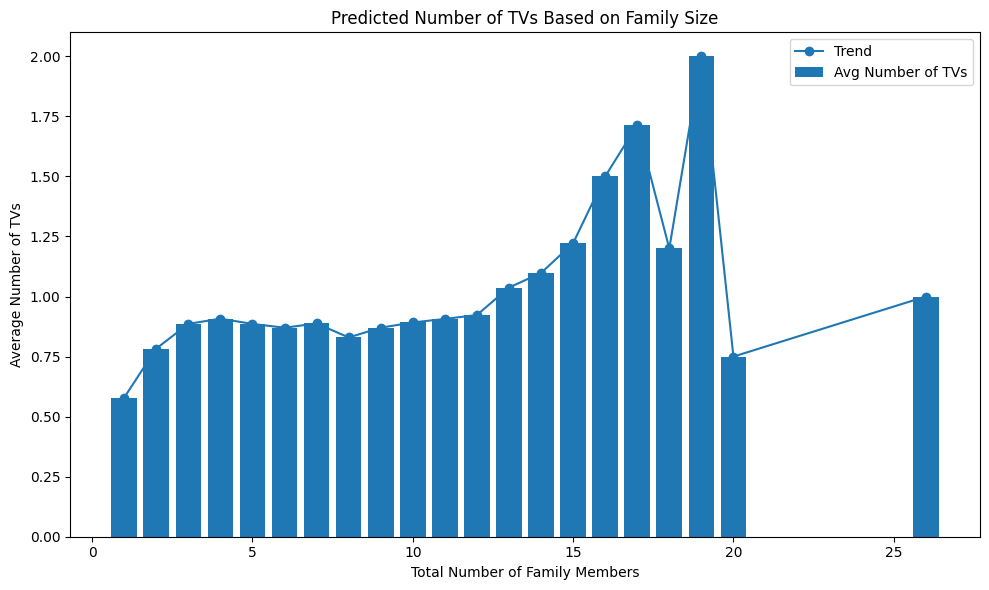

In [13]:
# Predicting Household Assets Based on Family Size
combo = df.groupby('Total Number of Family members')['Number of Television'].mean()

plt.figure(figsize=(10,6))

# Bar
plt.bar(combo.index, combo.values, label='Avg Number of TVs')

# Line Trend
plt.plot(combo.index, combo.values, marker='o', label='Trend')

plt.title('Predicted Number of TVs Based on Family Size')
plt.xlabel('Total Number of Family Members')
plt.ylabel('Average Number of TVs')
plt.legend()
plt.tight_layout()
plt.show()

<h3>INSIGHT #</h3>
<p>It show how the number of TVs a family owns relates to how many people live in the household. When the family size goes from one person up to about ten people, the average number of TVs slowly increases, which suggests that larger families need more access to entertainment or shared appliances. However, once families have more than ten members, the pattern becomes less stable and more unpredictable. Some very large families have more TVs, even reaching between one and two units, while others have fewer than expected. 

The sudden rises and drops in the line graph show that income also plays a big role. This means that even if a family is large, they may not own many TVs if they do not have enough financial resources. Because of this, the relationship between family size and TV ownership is not perfectly smooth.

In smaller families, the trend is clearer, but in bigger families, money differences cause the number of TVs to go up and down sharply. This shows that both family size and income affect TV ownership, especially for large households.</p>
<hr>

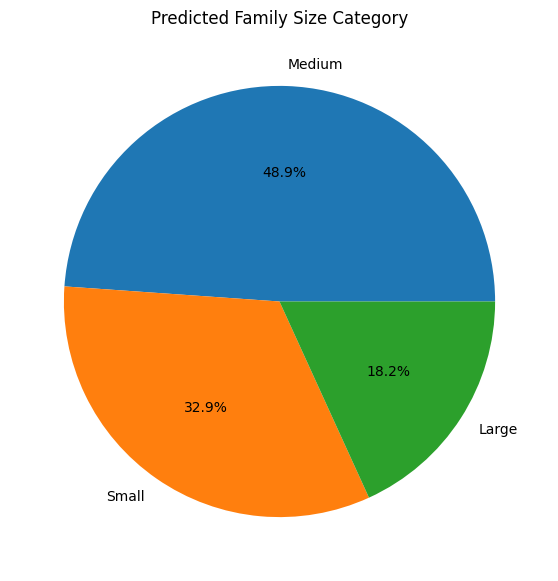

In [14]:
# Predicted Household “Size Category” Based on Number of Family
df['Family Size Category'] = pd.cut(
    df['Total Number of Family members'],
    bins=[0,3,6,20],
    labels=['Small','Medium','Large']
)

size_counts = df['Family Size Category'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(size_counts, labels=size_counts.index, autopct='%1.1f%%')

plt.title('Predicted Family Size Category')
plt.show()

<h3>INSIGHT #</h3>
<p>It shows the predicted family size categories provides a clear picture of how most households fall within different size groups. The largest part of the chart is the medium-sized families, which make up almost half of all households. This suggests that many families have around four to six members, which seems to be the most common household structure.
    
Small families are the second most common group, making up about a third of the total. This likely includes couples, single parents with one child, or households with only one or two people. The smallest portion of the chart belongs to large families, which make up less than one-fifth of all households. This means that households with more than six members are less frequent, possibly because larger families need more space, more resources, and higher income to support many members. 

Overall, the pie chart shows that while small and large families exist, most households fall into the medium-sized category, making it the most typical family size in the dataset.</p>
<hr>